# Mass-spring-damper benchmark: adaptive delayed-acceptance MCMC vs. baselines

A mass-spring-damper released from rest, `m x'' + c x' + k x = 0`. Mass is fixed; the
unknowns are stiffness `k` and damping `c`, inferred from a noisy observed trajectory.

**Four inference strategies** (implemented in `msd_methods.py`):

1. **HF-only Metropolis-Hastings** -- ground-truth reference; every step calls the
   expensive high-fidelity (HF) forward model.
2. **Pretrained** -- a POD-GP surrogate trained offline via greedy max-variance active
   learning, then frozen and used as if exact (the "Pretrained Model" arm in Riccius
   et al., 2025).
3. **Riccius-style online active learning** -- the surrogate is substituted for the
   likelihood and refined online via an uncertainty threshold, with no
   delayed-acceptance (DA) correction.
4. **Ours** -- the surrogate is refined online during an adaptive phase, guided by the
   MCMC path; once its accuracy stabilizes it is frozen and a delayed-acceptance chain
   generates the production samples, which carry the DA stationarity guarantee
   (unlike methods 2 and 3).

**Two comparisons.** Comparing `pretrained`'s frozen, uncorrected posterior directly
against `ours`'s DA-corrected posterior would only show that DA correction removes
surrogate bias -- true, but not this work's contribution. So the two questions are
kept separate:

- **Training cost**: `ours`'s online, MCMC-path-guided adaptive phase vs.
  `pretrained`'s offline, global active-learning procedure -- how much HF budget each
  needs to reach a trustworthy surrogate.
- **Posterior accuracy**: `hf_only` vs. `online_active` vs. `ours` (`pretrained`
  excluded, per above). `online_active` stays in this comparison to show that
  continual online refinement *without* DA correction still doesn't recover the true
  posterior.

All results below are aggregated over 25 independent problem instances, produced by
`run_sweep_convergence_driven.py --n-seeds 25`.

In [1]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from msd_methods import PARAM_NAMES, RESULTS_DIR, build_problem
from msd_plots import plot_accuracy_boxplots, plot_training_cost_boxplot

FIGURES_DIR = RESULTS_DIR / "figures"
SWEEP_PATH = RESULTS_DIR / "sweep_convergence_driven.jsonl"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Problem setup

One example problem instance: `theta_true` drawn from the prior, and a noisy
synthetic observation of the resulting trajectory.

theta_true: {'k': 58.21770123928726, 'c': 2.809360141291611}


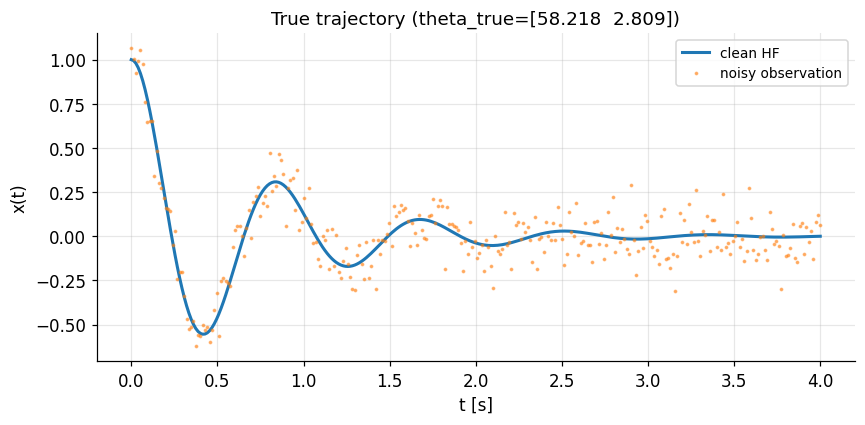

In [2]:
problem = build_problem(problem_seed=0, sigma_obs=0.1)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(problem.t, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(problem.t, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("t [s]")
ax.set_ylabel("x(t)")
ax.legend()
ax.set_title(f"True trajectory (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()


## Running the comparison

`run_sweep_convergence_driven.py --n-seeds 25` runs both comparisons above for 25
independent problem instances (fresh `theta_true`/observation and offline seed design
each; takes roughly an hour) and saves per-seed metrics to
`results/sweep_convergence_driven.jsonl` and per-seed figures to `results/figures/`.
This notebook loads and aggregates that output.

In [3]:
if not SWEEP_PATH.exists():
    print(f"{SWEEP_PATH} not found -- run `python run_sweep_convergence_driven.py --n-seeds 25` first.")
    sweep_rows = []
else:
    sweep_rows = [json.loads(line) for line in SWEEP_PATH.read_text().splitlines() if line.strip()]
    print(f"Loaded {len(sweep_rows)} seed(s) from {SWEEP_PATH}")


Loaded 25 seed(s) from /Users/filippozacchei/COde/MFDA_ActiveLearning/examples/toy_problem/results/sweep_convergence_driven.jsonl


## Example: surrogate fit and posterior (seed 0)

One example from the sweep: the trained surrogate's prediction at `theta_true` for
each method (top), and the pooled posterior for `hf_only`/`online_active`/`ours`
(bottom). The same two figures are saved for every seed in `results/figures/`.

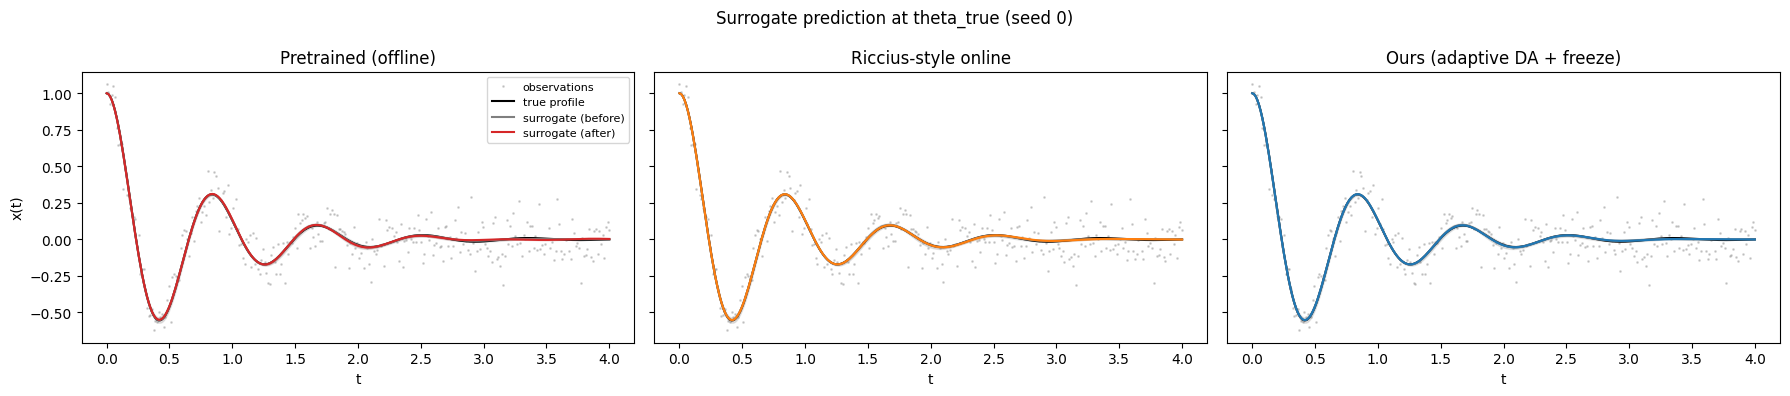

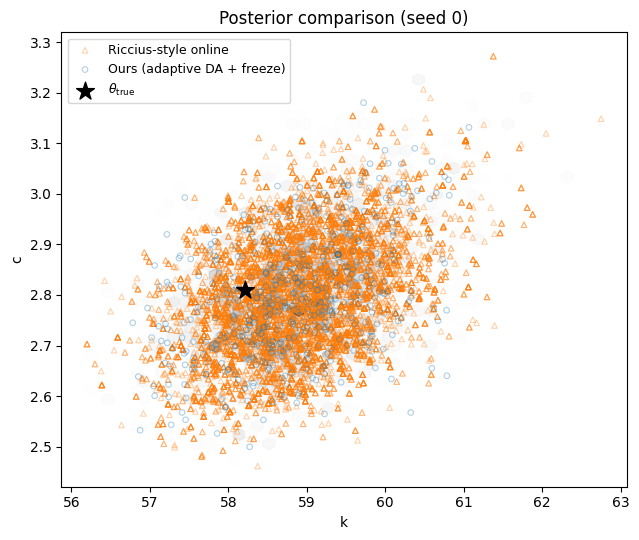

In [4]:
example_seed = sweep_rows[0]["seed"] if sweep_rows else 0
display(Image(filename=str(FIGURES_DIR / f"surrogate_comparison_seed_{example_seed}.png")))
display(Image(filename=str(FIGURES_DIR / f"posterior_scatter_seed_{example_seed}.png")))


## Training-cost comparison

Extra HF evaluations beyond the shared offline seed design -- `ours`'s online
adaptive phase vs. `pretrained`'s offline active-learning procedure -- across all
seeds.

        offline_extra_hf  online_extra_hf
mean           63.000000        41.520000
median         75.000000        41.000000
std            19.257033         3.489508

ours' adaptive-phase convergence rate: 100.0%


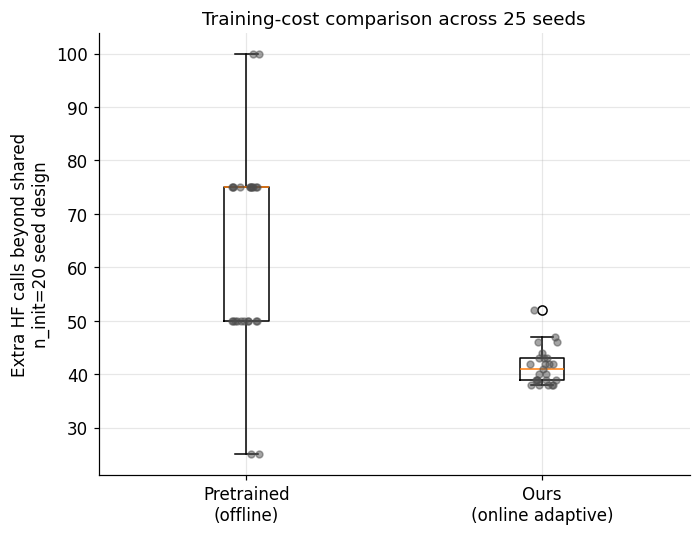

In [5]:
tc_df = pd.DataFrame([
    {
        "seed": r["seed"],
        "offline_extra_hf": r["training_cost"]["offline"]["n_hf_extra"],
        "online_extra_hf": r["training_cost"]["online"]["n_hf_extra"],
        "online_converged": r["training_cost"]["online"]["converged"],
    }
    for r in sweep_rows
])
print(tc_df[["offline_extra_hf", "online_extra_hf"]].agg(["mean", "median", "std"]))
print(f"\nours' adaptive-phase convergence rate: {tc_df['online_converged'].mean():.1%}")

fig = plot_training_cost_boxplot(
    tc_df["offline_extra_hf"].to_numpy(), tc_df["online_extra_hf"].to_numpy(), n_init=sweep_rows[0]["n_init"]
)
fig.savefig(FIGURES_DIR / "training_cost_sweep.png", bbox_inches="tight")


## Posterior-accuracy comparison

Cost to reach R-hat<=1.01 across 5 replicate chains, and distributional distance
(Wasserstein-2, KL) to the `hf_only` reference posterior, across all seeds.

method
hf_only          1.00
online_active    0.76
ours             1.00
Name: convergence_rate, dtype: float64

              total_coarse_evals                      n_hf_calls          \
                            mean  median          std       mean  median   
method                                                                     
hf_only                   1680.0  1500.0   405.174859    8405.00  7505.0   
online_active             3660.0  2000.0  3337.663854     205.64   128.0   
ours                      3220.0  3000.0   925.112606     749.00   705.0   

                              w2_ref                        kl_ref            \
                       std      mean    median       std      mean    median   
method                                                                         
hf_only        2025.874297       NaN       NaN       NaN       NaN       NaN   
online_active   396.313310  0.422415  0.198365  0.619783  0.243642  0.035905   
ours            185.022521  0.

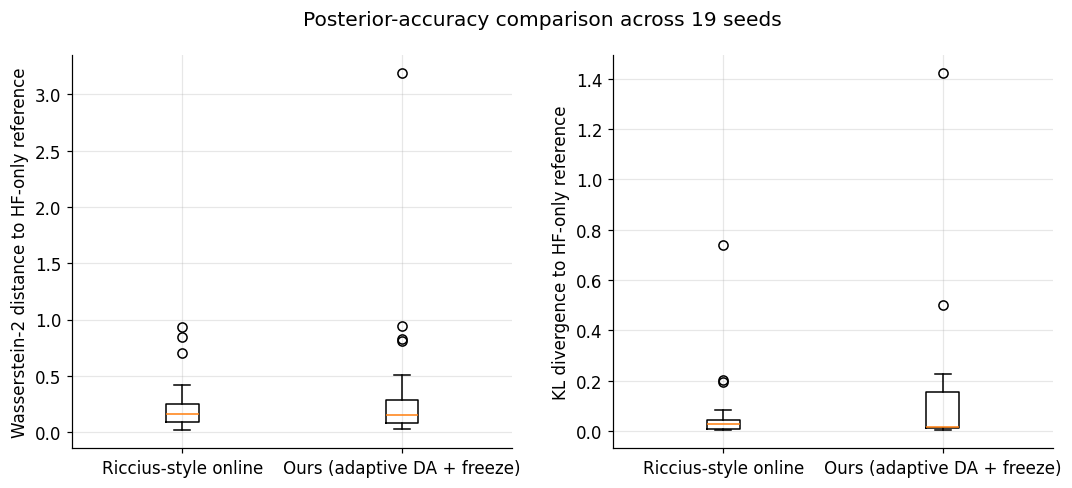

In [6]:
pa_rows = []
for r in sweep_rows:
    for method in ("hf_only", "online_active", "ours"):
        p = r["posterior"][method]
        pooled = p.get("pooled", {})
        pa_rows.append({
            "seed": r["seed"],
            "method": method,
            "converged": p["converged"],
            "total_coarse_evals": p["total_coarse_evals"],
            "n_hf_calls": pooled.get("n_hf_calls"),
            "w2_ref": pooled.get("wasserstein2_to_reference"),
            "kl_ref": pooled.get("kl_to_reference"),
            "rmse": pooled.get("rmse_to_truth"),
        })
pa_df = pd.DataFrame(pa_rows)
print(pa_df.groupby("method")["converged"].mean().rename("convergence_rate"))
print()
print(pa_df.groupby("method")[["total_coarse_evals", "n_hf_calls", "w2_ref", "kl_ref", "rmse"]].agg(["mean", "median", "std"]))

converged = pa_df[pa_df["converged"]]
method_order = ("online_active", "ours")
w2_by_method = {m: converged.loc[converged["method"] == m, "w2_ref"].dropna().to_numpy() for m in method_order}
kl_by_method = {m: converged.loc[converged["method"] == m, "kl_ref"].dropna().to_numpy() for m in method_order}

fig = plot_accuracy_boxplots(w2_by_method, kl_by_method, method_order=method_order)
fig.savefig(FIGURES_DIR / "posterior_accuracy_sweep.png", bbox_inches="tight")
